Phase-1: Dataset Preparation

Mounting the google drive to store the dataset and the model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defining the dataset path.

In [ ]:
train_path = "/content/drive/MyDrive/Titanic_Project/train.csv"
test_path = "/content/drive/MyDrive/Titanic_Project/test.csv"
gender_path = "/content/drive/MyDrive/Titanic_Project/gender_submission.csv"

Loading the datasets

In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
gender_df = pd.read_csv(gender_path)

viewing the data

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


checking the shape of the dataset.

In [ ]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


column names.

In [ ]:
print(train_df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Dataset Information which shows how many null values are present etc.

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


statistical summary

In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


check missing values

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


check survival distribution

In [ ]:
train_df['Survived'].value_counts()

,count
Survived,
0,549
1,342


visvualize survival count

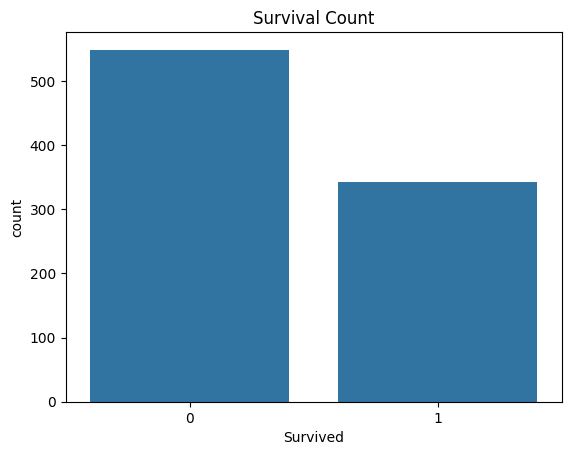

In [ ]:
sns.countplot(x='Survived', data=train_df)

plt.title("Survival Count")
plt.show()

Phase 2 — Exploratory Data Analysis (EDA)
In this phase you will:
Understand survival patterns
Find important features
Discover relationships in data
Decide which features are useful for ML

Set Visualization Style

In [ ]:
plt.style.use('ggplot')
sns.set_style('whitegrid')

Survival Count Visualization

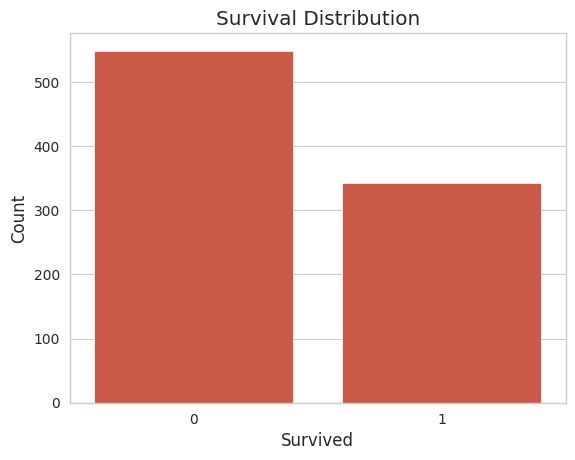

In [ ]:
sns.countplot(x='Survived', data=train_df)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

Survival Percentage

In [ ]:
survival_rate = train_df['Survived'].value_counts(normalize=True) * 100

print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


Survival vs Gender

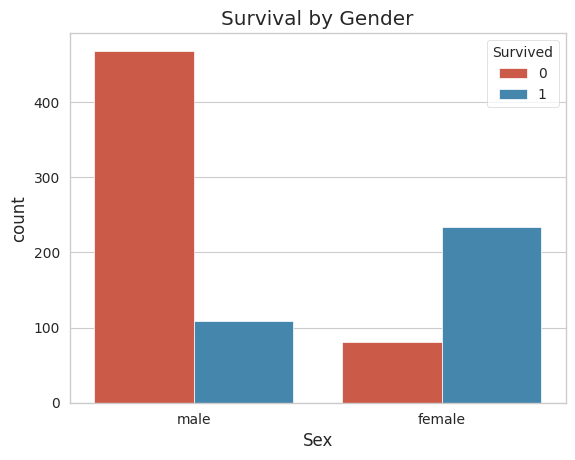

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=train_df)

plt.title("Survival by Gender")
plt.show()

Survival Percentage by Gender

In [ ]:
gender_survival = train_df.groupby('Sex')['Survived'].mean() * 100

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Survival vs Passenger Class

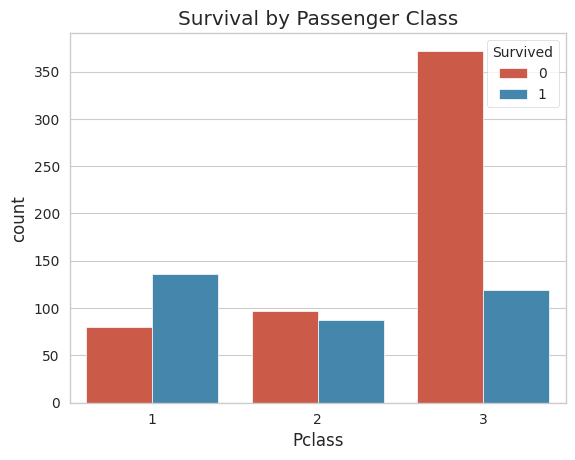

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=train_df)

plt.title("Survival by Passenger Class")
plt.show()

Passenger Class Survival Percentage

In [ ]:
pclass_survival = train_df.groupby('Pclass')['Survived'].mean() * 100

print(pclass_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


Age Distribution

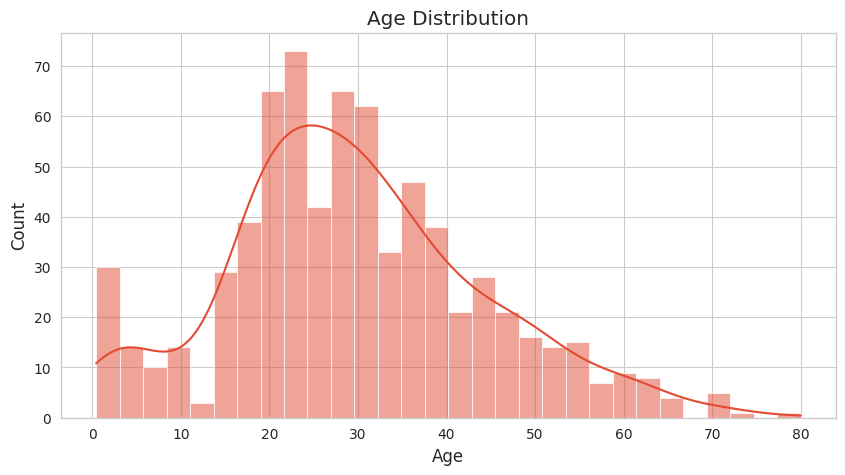

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

Age vs Survival

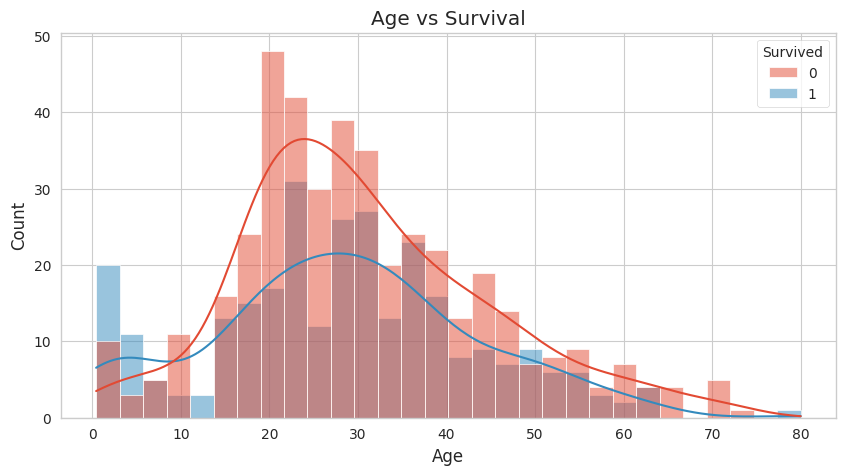

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(data=train_df,
             x='Age',
             hue='Survived',
             bins=30,
             kde=True)

plt.title("Age vs Survival")
plt.show()

Fare Distribution

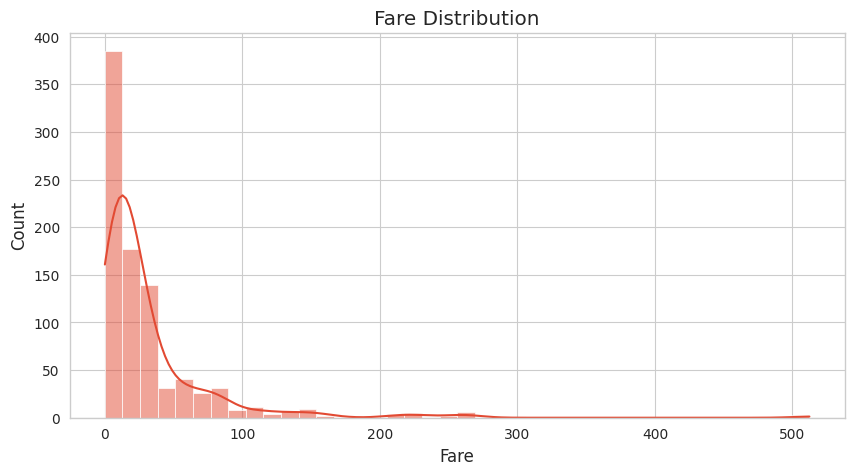

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['Fare'], bins=40, kde=True)

plt.title("Fare Distribution")
plt.show()

Fare vs Survival

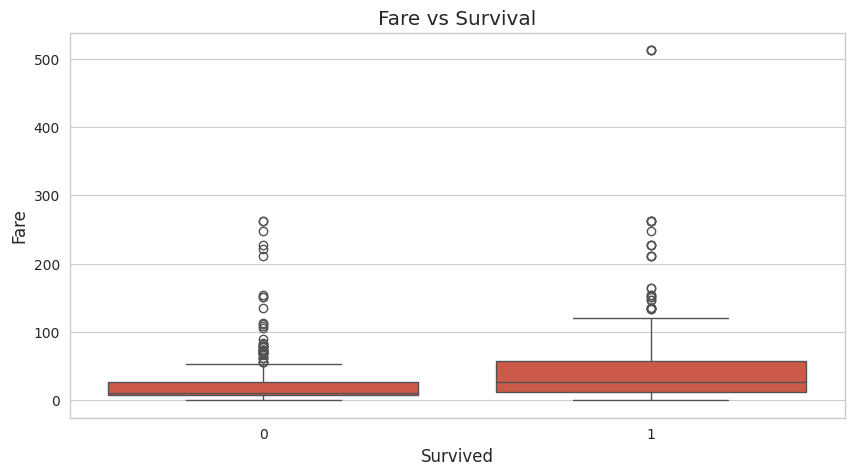

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Survived', y='Fare', data=train_df)

plt.title("Fare vs Survival")
plt.show()

Embarked vs Survival

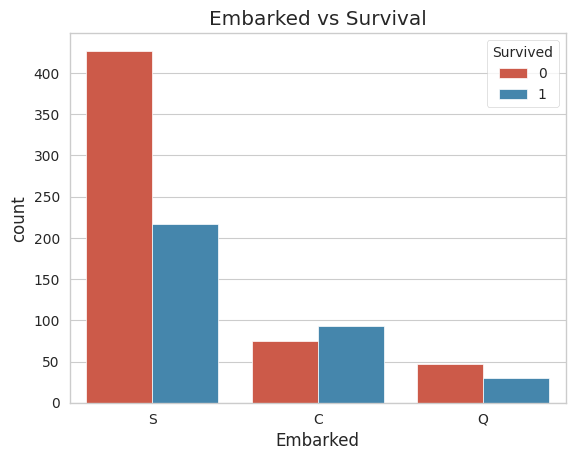

In [ ]:
sns.countplot(x='Embarked', hue='Survived', data=train_df)

plt.title("Embarked vs Survival")
plt.show()

Family Size Analysis

In [ ]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

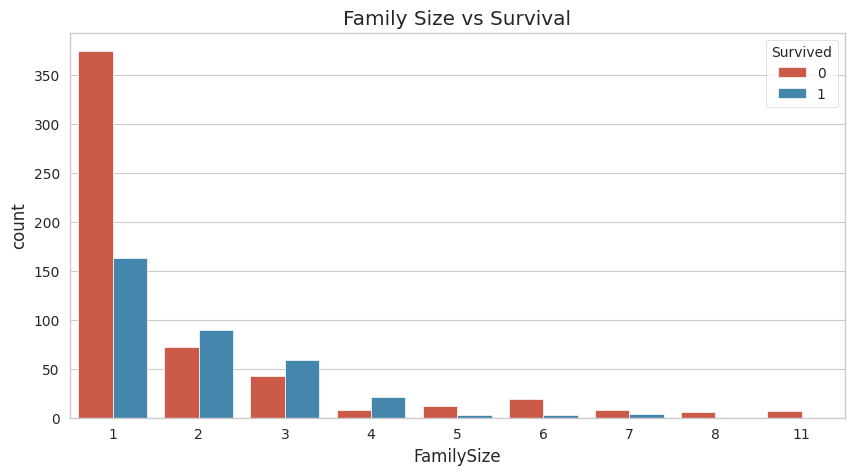

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='FamilySize', hue='Survived', data=train_df)

plt.title("Family Size vs Survival")
plt.show()

Correlation Heatmap


In [ ]:
temp_df = train_df.copy()

temp_df['Sex'] = temp_df['Sex'].map({'male':0, 'female':1})

temp_df['Embarked'] = temp_df['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

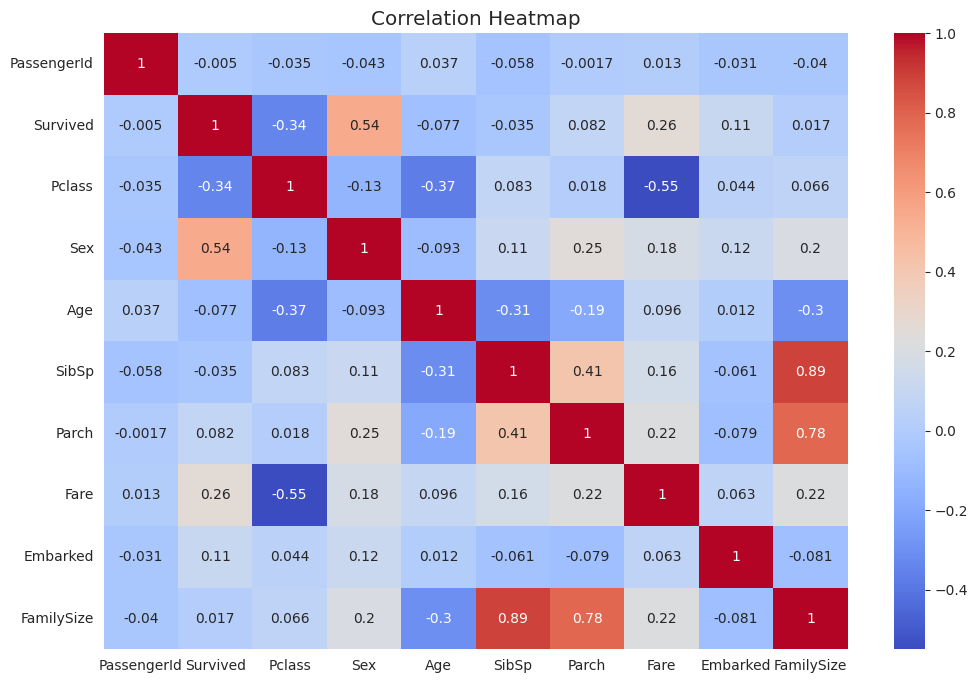

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(temp_df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Missing Values Visualization

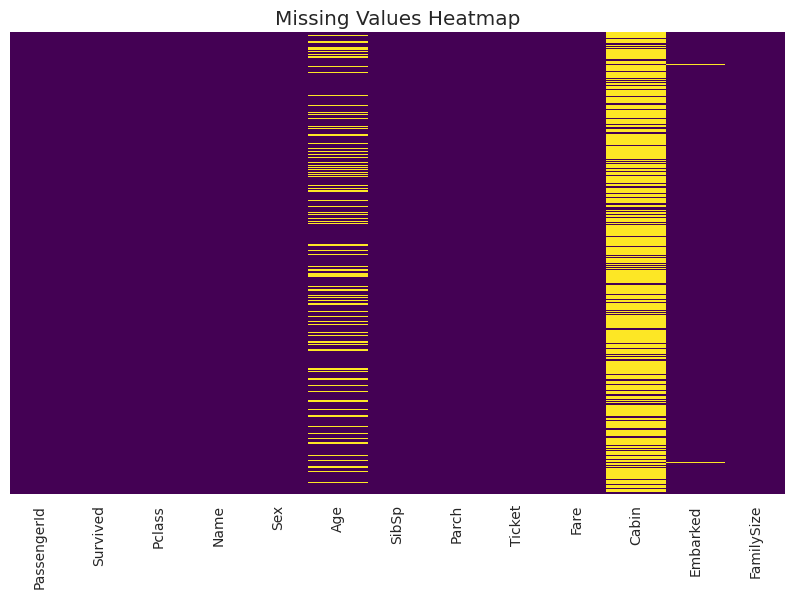

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(train_df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

Pairplot

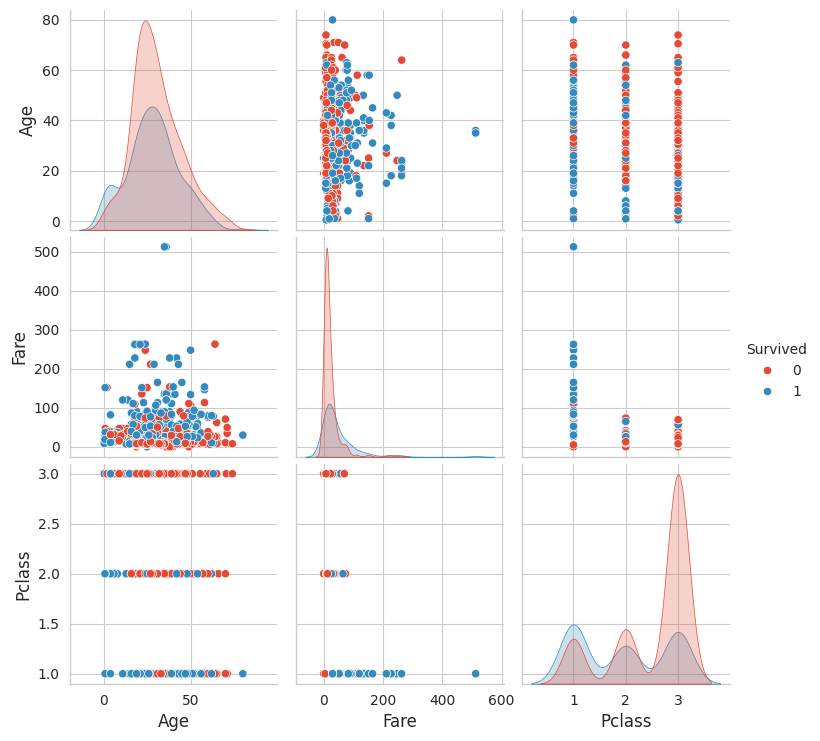

In [ ]:
sns.pairplot(train_df[['Survived',
                       'Age',
                       'Fare',
                       'Pclass']],
             hue='Survived')

plt.show()

Phase 3 — Data Cleaning + Preprocessing
In this phase we will:
handle missing values
encode categorical columns
create useful features
remove unnecessary columns
prepare final ML-ready dataset


Check Missing Values Again

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Fill Missing Age Values

In [ ]:
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

/tmp/ipykernel_3393/1580848397.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)


In [ ]:
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

/tmp/ipykernel_3393/1811889073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Age'].fillna(test_df['Age'].median(), inplace=True)


Fill Missing Embarked Values

In [ ]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_3393/1613448763.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)


Fill Missing Fare Values in Test Data

In [ ]:
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

/tmp/ipykernel_3393/4271572204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)


Handle Cabin Column

In [ ]:
train_df.drop('Cabin', axis=1, inplace=True)
test_df.drop('Cabin', axis=1, inplace=True)

Create Family Size Feature

In [ ]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

Create IsAlone Feature
If family size is 1:
passenger was alone

In [ ]:
train_df['IsAlone'] = 0

train_df.loc[train_df['FamilySize'] == 1, 'IsAlone'] = 1

In [ ]:
test_df['IsAlone'] = 0

test_df.loc[test_df['FamilySize'] == 1, 'IsAlone'] = 1

Extract Title from Name
This improves model accuracy significantly.
Examples:
Mr
Mrs
Miss
Master

In [ ]:
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3393/513419185.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [ ]:
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3393/366814549.py:1: SyntaxWarning: invalid escape sequence '\.'
  test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Simplify Rare Titles

In [ ]:
train_df['Title'] = train_df['Title'].replace(
    ['Lady', 'Countess','Capt', 'Col',
     'Don', 'Dr', 'Major', 'Rev',
     'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

train_df['Title'] = train_df['Title'].replace('Mlle', 'Miss')
train_df['Title'] = train_df['Title'].replace('Ms', 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

In [ ]:
test_df['Title'] = test_df['Title'].replace(
    ['Lady', 'Countess','Capt', 'Col',
     'Don', 'Dr', 'Major', 'Rev',
     'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

test_df['Title'] = test_df['Title'].replace('Mlle', 'Miss')
test_df['Title'] = test_df['Title'].replace('Ms', 'Miss')
test_df['Title'] = test_df['Title'].replace('Mme', 'Mrs')

Encode Categorical Features

In [ ]:
train_df['Sex'] = train_df['Sex'].map({
    'male': 0,
    'female': 1
})

In [ ]:
test_df['Sex'] = test_df['Sex'].map({
    'male': 0,
    'female': 1
})

In [ ]:
train_df['Embarked'] = train_df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [ ]:
test_df['Embarked'] = test_df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [ ]:
title_mapping = {
    "Mr": 1,
    "Miss": 2,
    "Mrs": 3,
    "Master": 4,
    "Rare": 5
}

train_df['Title'] = train_df['Title'].map(title_mapping)
train_df['Title'] = train_df['Title'].fillna(0)

In [ ]:
test_df['Title'] = test_df['Title'].map(title_mapping)
test_df['Title'] = test_df['Title'].fillna(0)

Drop Unnecessary Columns

Remove:
Name
Ticket
PassengerId
These are not directly useful for prediction.

Save PassengerId First


In [ ]:
test_passenger_ids = test_df['PassengerId']

Drop Columns


In [ ]:
train_df.drop(['Name', 'Ticket', 'PassengerId'],
              axis=1,
              inplace=True)

test_df.drop(['Name', 'Ticket', 'PassengerId'],
             axis=1,
             inplace=True)

Verify Missing Values Again

In [ ]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
dtype: int64
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
dtype: int64


Check Final Dataset

In [ ]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,0,22.0,1,0,7.2500,0,2,0,1
1,1,1,1,38.0,1,0,71.2833,1,2,0,3
2,1,3,1,26.0,0,0,7.9250,0,1,1,2
3,1,1,1,35.0,1,0,53.1000,0,2,0,3
4,0,3,0,35.0,0,0,8.0500,0,1,1,1


Separate Features and Target

In [ ]:
X = train_df.drop('Survived', axis=1)

In [ ]:
y = train_df['Survived']

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Check Shapes

In [ ]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(712, 10)
(179, 10)
(712,)
(179,)


Phase 4 — Model Building + Training + Evaluation
In this phase we will build multiple ML models and compare them.
Models:
Logistic Regression
Decision Tree
Random Forest ⭐
XGBoost ⭐⭐

Import ML Libraries

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

=========================================================
MODEL 1 — Logistic Regression
=========================================================


Train Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predict Validation Data

In [ ]:
y_pred_log = log_model.predict(X_valid)

Evaluate Logistic Regression

In [ ]:
log_accuracy = accuracy_score(y_valid, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7932960893854749


In [ ]:
print(confusion_matrix(y_valid, y_pred_log))

[[87 18]
 [19 55]]


In [ ]:
print(classification_report(y_valid, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



=========================================================
MODEL 2 — Decision Tree
=========================================================

Train Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_valid)

In [ ]:
dt_accuracy = accuracy_score(y_valid, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print(confusion_matrix(y_valid, y_pred_dt))

print(classification_report(y_valid, y_pred_dt))

Decision Tree Accuracy: 0.8324022346368715
[[94 11]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



=========================================================
MODEL 3 — Random Forest ⭐
=========================================================


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_valid)

In [ ]:
rf_accuracy = accuracy_score(y_valid, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print(confusion_matrix(y_valid, y_pred_rf))

print(classification_report(y_valid, y_pred_rf))

Random Forest Accuracy: 0.8268156424581006
[[92 13]
 [18 56]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



=========================================================
MODEL 4 — XGBoost ⭐⭐
=========================================================


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_valid)

In [ ]:
xgb_accuracy = accuracy_score(y_valid, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

print(confusion_matrix(y_valid, y_pred_xgb))

print(classification_report(y_valid, y_pred_xgb))

XGBoost Accuracy: 0.8324022346368715
[[91 14]
 [16 58]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
model_scores = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(model_scores)

                 Model  Accuracy
0  Logistic Regression  0.793296
1        Decision Tree  0.832402
2        Random Forest  0.826816
3              XGBoost  0.832402


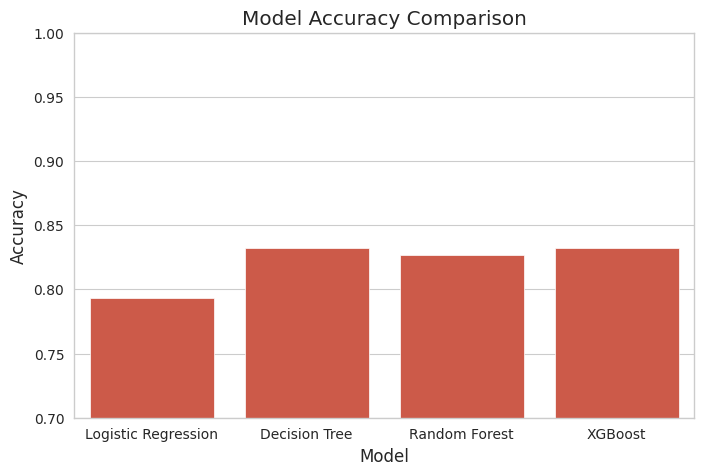

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_scores
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.7, 1.0)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
9       Title    0.295990
1         Sex    0.263488
5        Fare    0.125590
0      Pclass    0.114760
2         Age    0.064772
7  FamilySize    0.054408
3       SibSp    0.038709
4       Parch    0.017833
6    Embarked    0.016803
8     IsAlone    0.007647


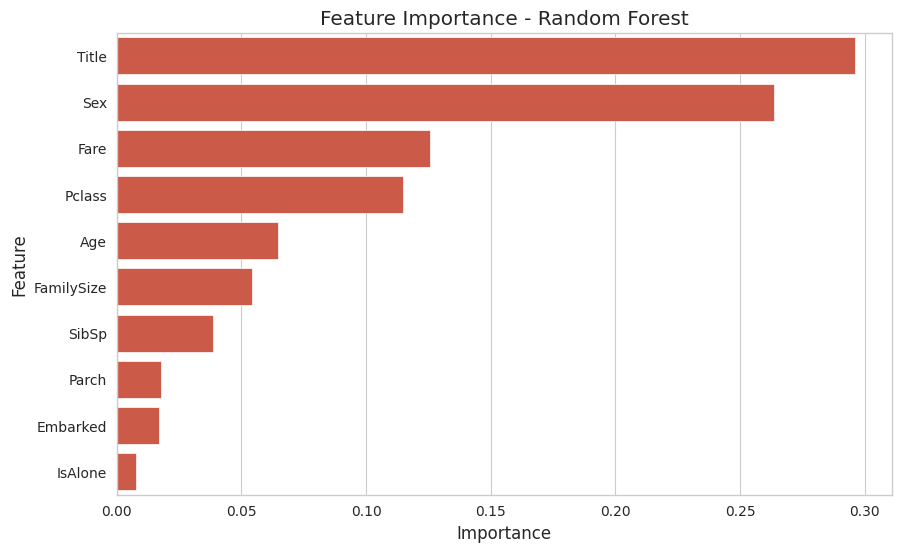

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

Phase 5 — Hyperparameter Tuning + Final Prediction + Kaggle Submission
In this phase we will:
Improve model accuracy
Tune Random Forest / XGBoost
Train final model
Predict on test.csv
Create submission.csv


=========================================================
PART 1 — Hyperparameter Tuning
=========================================================
We will tune:
Random Forest
because:
beginner friendly
stable
strong accuracy

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 5, 6, 7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.8356249384418399


In [ ]:
best_rf_model = grid_search.best_estimator_

In [ ]:
y_pred_best_rf = best_rf_model.predict(X_valid)

best_rf_accuracy = accuracy_score(
    y_valid,
    y_pred_best_rf
)

print("Tuned Random Forest Accuracy:")
print(best_rf_accuracy)

Tuned Random Forest Accuracy:
0.8268156424581006


=========================================================
PART 2 — Train Final Model on Full Dataset
=========================================================
Now train using ALL training data.

In [ ]:
X_full = train_df.drop('Survived', axis=1)

y_full = train_df['Survived']

In [ ]:
best_rf_model.fit(X_full, y_full)

RandomForestClassifier(max_depth=6, min_samples_split=5, random_state=42)

=========================================================
PART 3 — Predict Test Dataset
=========================================================


In [ ]:
test_predictions = best_rf_model.predict(test_df)

In [ ]:
print(test_predictions[:20])

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]


In [ ]:
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

In [ ]:
print(test_predictions[:20])

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]


In [ ]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv(
    'submission.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(best_rf_model, 'titanic_model.pkl')

['titanic_model.pkl']

In [ ]:
files.download('titanic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install gradio

In [ ]:
import joblib

joblib.dump(best_rf_model, 'titanic_model.pkl')

['titanic_model.pkl']

In [ ]:
import gradio as gr
import numpy as np
import joblib

In [ ]:
model = joblib.load('titanic_model.pkl')

In [ ]:
def predict_survival(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    family_size,
    is_alone,
    title
):

    # Convert gender
    sex = 0 if sex == "Male" else 1

    # Convert embarked
    embarked_mapping = {
        "Southampton": 0,
        "Cherbourg": 1,
        "Queenstown": 2
    }

    embarked = embarked_mapping[embarked]

    # Convert title
    title_mapping = {
        "Mr": 1,
        "Miss": 2,
        "Mrs": 3,
        "Master": 4,
        "Rare": 5
    }

    title = title_mapping[title]

    # Create feature array
    features = np.array([[
        pclass,
        sex,
        age,
        sibsp,
        parch,
        fare,
        embarked,
        family_size,
        is_alone,
        title
    ]])

    # Predict
    prediction = model.predict(features)[0]

    # Probability
    probability = model.predict_proba(features)[0][prediction]

    # Output result
    if prediction == 1:
        return f"Passenger Survived ✅ (Confidence: {probability:.2f})"
    else:
        return f"Passenger Did Not Survive ❌ (Confidence: {probability:.2f})"

In [ ]:
interface = gr.Interface(
    fn=predict_survival,

    inputs=[
        gr.Dropdown([1,2,3], label="Passenger Class"),

        gr.Radio(
            ["Male", "Female"],
            label="Gender"
        ),

        gr.Slider(
            0, 80,
            step=1,
            label="Age"
        ),

        gr.Slider(
            0, 10,
            step=1,
            label="Siblings/Spouse"
        ),

        gr.Slider(
            0, 10,
            step=1,
            label="Parents/Children"
        ),

        gr.Slider(
            0, 600,
            step=1,
            label="Fare"
        ),

        gr.Dropdown(
            ["Southampton",
             "Cherbourg",
             "Queenstown"],
            label="Embarked"
        ),

        gr.Slider(
            1, 15,
            step=1,
            label="Family Size"
        ),

        gr.Radio(
            [0,1],
            label="Is Alone? (1 = Yes)"
        ),

        gr.Dropdown(
            ["Mr",
             "Miss",
             "Mrs",
             "Master",
             "Rare"],
            label="Title"
        )
    ],

    outputs="text",

    title="Titanic Survival Prediction",

    description="""
    Enter passenger details to predict whether
    the passenger would survive the Titanic disaster.
    """
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://05fe594d665a6f255d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile gradio_app.py

import gradio as gr
import numpy as np
import joblib

# Load trained model
model = joblib.load('titanic_model.pkl')

# Prediction function
def predict_survival(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    title
):

    # Convert categorical values
    sex = 0 if sex == "Male" else 1

    embarked_mapping = {
        "Southampton": 0,
        "Cherbourg": 1,
        "Queenstown": 2
    }

    embarked = embarked_mapping[embarked]

    title_mapping = {
        "Mr": 1,
        "Miss": 2,
        "Mrs": 3,
        "Master": 4,
        "Rare": 5
    }

    title = title_mapping[title]

    # Feature engineering
    family_size = sibsp + parch + 1

    is_alone = 1 if family_size == 1 else 0

    # Final input
    features = np.array([[
        pclass,
        sex,
        age,
        sibsp,
        parch,
        fare,
        embarked,
        family_size,
        is_alone,
        title
    ]])

    # Prediction
    prediction = model.predict(features)[0]

    probability = model.predict_proba(features)[0][prediction]

    # Result
    if prediction == 1:
        return f"Passenger Survived ✅ (Confidence: {probability:.2f})"

    else:
        return f"Passenger Did Not Survive ❌ (Confidence: {probability:.2f})"


# Gradio Interface
interface = gr.Interface(
    fn=predict_survival,

    inputs=[

        gr.Dropdown(
            [1, 2, 3],
            label="Passenger Class"
        ),

        gr.Radio(
            ["Male", "Female"],
            label="Gender"
        ),

        gr.Slider(
            0, 80,
            step=1,
            label="Age"
        ),

        gr.Slider(
            0, 10,
            step=1,
            label="Siblings/Spouse"
        ),

        gr.Slider(
            0, 10,
            step=1,
            label="Parents/Children"
        ),

        gr.Slider(
            0, 600,
            step=1,
            label="Fare"
        ),

        gr.Dropdown(
            ["Southampton",
             "Cherbourg",
             "Queenstown"],
            label="Embarked"
        ),

        gr.Dropdown(
            ["Mr",
             "Miss",
             "Mrs",
             "Master",
             "Rare"],
            label="Title"
        )
    ],

    outputs="text",

    title="Titanic Survival Prediction",

    description="""
    Enter passenger details to predict whether
    the passenger survived the Titanic disaster.
    """
)

# Launch app
interface.launch()

Overwriting gradio_app.py


In [ ]:
!ls

drive  gradio_app.py  sample_data  submission.csv  titanic_model.pkl


In [ ]:
from google.colab import files
files.download('gradio_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>